# `FULL` training run — Colab

The local machine runs `SMOKE` (4 epochs, T=50, 2.5M params) to prove the code path is correct.
This notebook runs the real thing: **`FULL` — 100 epochs over ~18k day-images, T=1000 linear,
128 base channels, ~35M params** — on a GPU, and writes a checkpoint you can pull back down.

It is the *same code* as `01_wavelet_ddpm.ipynb`, imported from `src/diffmodel` rather than
re-typed. Nothing here is Colab-only except the mechanics of getting the repo onto the box and
the checkpoint off it. `config.FULL` is the single source of truth for every hyperparameter.

**Runtime:** pick a GPU (Runtime → Change runtime type → T4 or better). Expect roughly
1.5–4 hours end to end on a T4 depending on the batch size that fits. The run checkpoints every
`cfg.ckpt_every` epochs and **resumes** from the last checkpoint, so a disconnect costs you at
most that many epochs — mount Drive in §2 and it costs nothing at all.

**Order:** run every cell top to bottom. §4 is the long one.

## 1. Machine, and the repo

In [1]:
!nvidia-smi || echo "NO GPU — Runtime > Change runtime type > T4. FULL on CPU is not worth starting."

Fri Aug 28 21:10:23 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-40GB          Off |   00000000:00:04.0 Off |                    0 |
| N/A   37C    P0             50W /  400W |       0MiB /  40960MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [2]:
# Repo is PUBLIC — plain anonymous clone, no token needed.
import os, subprocess
from pathlib import Path

REPO_USER = "Bromine185"
REPO_NAME = "diff_model"
REPO = Path("/content") / REPO_NAME

if not REPO.exists():
    token = os.environ.get("GITHUB_TOKEN", "")   # empty string → no auth prefix
    auth  = f"{token}@" if token else ""
    url   = f"https://{auth}github.com/{REPO_USER}/{REPO_NAME}.git"
    subprocess.run(["git", "clone", "--depth", "1", url, str(REPO)], check=True)
    del auth, url
else:
    subprocess.run(["git", "-C", str(REPO), "pull", "--ff-only"], check=False)

%cd {REPO}
!git log --oneline -1

/content/diff_model
7e32fe7 (grafted, HEAD -> master, origin/master, origin/HEAD) Fix the DDPM sampler blow-up; deseasonalise the clustering metric


In [3]:
from pathlib import Path
import sys

REPO = Path("/content/diff_model")
src = REPO / "src"
assert (src / "diffmodel" / "config.py").exists(), src
sys.path.insert(0, str(src))

In [4]:
# Colab ships torch/numpy/pandas/pyarrow/tqdm/matplotlib. Only install what is actually missing,
# and pin nothing that would drag in a different torch.
import importlib, subprocess, sys

for module, package in [("arch", "arch>=7.0"), ("pywt", "PyWavelets>=1.7")]:
    if importlib.util.find_spec(module) is None:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", package], check=True)

sys.path.insert(0, str(REPO / "src"))

import numpy as np, torch
from diffmodel.config import get_config, pick_device
print(f"torch {torch.__version__}  cuda={torch.cuda.is_available()}  device={pick_device()}")

torch 2.11.0+cu128  cuda=True  device=cuda


## 2. Where the checkpoint lives (mount Drive — do it)

Colab VMs are reclaimed without warning. `checkpoints/` under `/content` dies with the VM;
a Drive folder does not, and `train(resume=True)` will pick the run back up exactly where the
last checkpoint left it. Skip this cell only for a throwaway run.

In [5]:
USE_DRIVE = True     # set False for a throwaway run that you do not mind losing

CKPT_DIR = REPO / "checkpoints"
if USE_DRIVE:
    from google.colab import drive
    drive.mount("/content/drive")
    CKPT_DIR = Path("/content/drive/MyDrive/diff_model_checkpoints")
CKPT_DIR.mkdir(parents=True, exist_ok=True)
print("checkpoints ->", CKPT_DIR)
print("existing:", sorted(p.name for p in CKPT_DIR.glob("*.pt")) or "none yet")

Mounted at /content/drive
checkpoints -> /content/drive/MyDrive/diff_model_checkpoints
existing: none yet


## 3. Config and data

`get_config("FULL")` is the preset; the only thing overridden is where checkpoints go. Everything
below — image geometry, schedule, widths, epochs, the `x0_clamp` safety net — comes from
`src/diffmodel/config.py` so that this run is reproducible from the repo alone.

`batch_size` is the one number worth touching: if §4 raises `CUDA out of memory`, halve it and
re-run from here. Loss is averaged per image, so the curve stays comparable across batch sizes.

In [6]:
from diffmodel.pipeline import prepare

cfg = get_config("FULL", ckpt_dir=str(CKPT_DIR))
# cfg = get_config("FULL", ckpt_dir=str(CKPT_DIR), batch_size=32)   # <- if OOM

device = pick_device()
data = prepare(cfg)
print(data.summary())
print(f"\npreset {cfg.name}: T={cfg.timesteps} ({cfg.beta_schedule}), {cfg.epochs} epochs, "
      f"batch {cfg.batch_size}, lr {cfg.lr}, base_channels {cfg.base_channels}, "
      f"x0_clamp {cfg.x0_clamp}")

winsorised fraction at 10 sigma: returns=0.00%, spread=0.07%, volume=0.00%
train (18311, 3, 8, 128)  val (3623, 3, 8, 128)
  train sessions 50, val sessions 10
  image range [-8.49, 8.49], std 0.333
train (18311, 3, 8, 128)  val (3623, 3, 8, 128)
  train sessions 50, val sessions 10
  image range [-8.49, 8.49], std 0.333

preset FULL: T=1000 (linear), 100 epochs, batch 64, lr 0.0001, base_channels 128, x0_clamp 6.5


In [7]:
# The transform must invert on THIS split before an epoch is spent training on it.
report = data.codec.roundtrip_report(data.train_series[:256])
print("codec round-trip, max |x - inv(fwd(x))| / std, per channel:")
for k, v in report.items():
    print(f"  {k:8s} {v:.3e}")

codec round-trip, max |x - inv(fwd(x))| / std, per channel:
  returns  5.914e-07
  spread   7.032e+00
  volume   6.607e-06


## 4. Train

Long cell. It prints one line per epoch and writes `full_latest.pt` every `cfg.ckpt_every`
epochs. **If the session drops, re-run §1–§3 and then this cell**: `resume=True` reads the
checkpoint back — model, EMA shadow, optimiser state, loss history — and continues from the
next epoch.

In [8]:
from diffmodel.unet import UNet
from diffmodel.train import train

model = UNet(
    in_channels=3,
    base_channels=cfg.base_channels,
    channel_mults=cfg.channel_mults,
    num_res_blocks=cfg.num_res_blocks,
    attention_at_bottleneck=cfg.attention_at_bottleneck,
    dropout=cfg.dropout,
)
model, ema, history, sched = train(
    model, data.train_images, cfg, device,
    val_images=data.val_images, resume=True, progress=True,
)
print(f"\ndone. {len(history.train_loss)} epochs, "
      f"final train {history.train_loss[-1]:.4f}"
      + (f", val(ema) {history.val_loss[-1]:.4f}" if history.val_loss else ""))

training FULL: 18,311 images, 57.57M params, T=1000 (linear), 100 epochs on cuda


epoch 1/100:   0%|          | 0/286 [00:00<?, ?it/s]

epoch   1/100  train 0.1657  21.6s  val(ema) 0.7409


epoch 2/100:   0%|          | 0/286 [00:00<?, ?it/s]

epoch   2/100  train 0.0383  20.0s  val(ema) 0.4416


...

epoch  98/100  train 0.0205  20.1s  val(ema) 0.0184


epoch 99/100:   0%|          | 0/286 [00:00<?, ?it/s]

epoch  99/100  train 0.0203  20.0s  val(ema) 0.0184


epoch 100/100:   0%|          | 0/286 [00:00<?, ?it/s]

epoch 100/100  train 0.0201  20.0s  val(ema) 0.0184

done. 100 epochs, final train 0.0201, val(ema) 0.0184


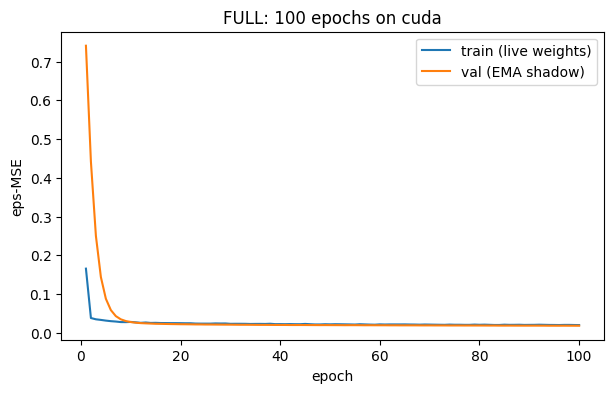

In [9]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(range(1, len(history.train_loss) + 1), history.train_loss, label="train (live weights)")
if history.val_loss:
    ax.plot(range(1, len(history.val_loss) + 1), history.val_loss, label="val (EMA shadow)")
ax.set_xlabel("epoch"); ax.set_ylabel("eps-MSE"); ax.legend()
ax.set_title(f"{cfg.name}: {len(history.train_loss)} epochs on {device}")
plt.show()

## 5. Sample, and the one diagnostic that matters first

Before any stylized fact: **image-space std against the real 0.333**. An undertrained diffusion
model does not produce slightly-wrong series, it produces pixels outside the range the codec was
fitted on, which the decoder then clamps — and a fully clamped sample can score *well* on
columns that reward a flat line. Read the saturation fractions before reading anything else.

Sampling passes `cfg.x0_clamp` (the data-derived bound on the implied clean image) and an
explicit labelled generator, so this draw is reproducible and independent of every other stream.

In [10]:
from diffmodel import ddpm
from diffmodel.config import BARS_PER_DAY
from diffmodel.seeding import torch_generator
from diffmodel.wavelet import image_to_series, invert_level_stats

N_GEN = 512
images = ddpm.sample(
    ema.shadow, (N_GEN, *cfg.image_shape), sched.to(device), device,
    x0_clamp=cfg.x0_clamp, generator=torch_generator("colab-full-sample"), progress=True,
).cpu().numpy().astype(np.float64)

normed = image_to_series(
    invert_level_stats(images, data.codec.level_stats, data.codec.image_scale), BARS_PER_DAY
)
sat = data.codec.day_transform.saturated_report(normed)

print(f"image-space std {images.std():.4g}  vs real {data.train_images.std():.4g}")
print(f"decoder inputs hitting the +/-{cfg.winsor_sigma:g} sigma clamp: "
      + ", ".join(f"{k}={v:.1%}" for k, v in sat.items()))

synth = data.codec.decode(images)
print(f"decoded synthetic series: {synth.shape}")

sampling:   0%|          | 0/1000 [00:00<?, ?it/s]

image-space std 0.3063  vs real 0.3333
decoder inputs hitting the +/-10 sigma clamp: returns=0.0%, spread=0.0%, volume=0.0%
decoded synthetic series: (512, 3, 78)


In [11]:
# Stylized facts, synthetic vs the held-out real split. Same machinery the scorecard uses, so
# these numbers are comparable to the classical-baseline rows in RESEARCH.md Phase 5.
from diffmodel.evaluate import RET, StylizedFacts, compare, intraday_profile

real = data.val_series
profile = intraday_profile(real, RET, absolute=True)   # the REAL profile, for both sides
d = compare(
    StylizedFacts.measure(real, deseasonal_profile=profile),
    StylizedFacts.measure(synth, deseasonal_profile=profile),
)
width = max(len(k) for k in d)
for k, v in d.items():
    print(f"  {k:<{width}s}  {v:.4f}")
print("\nlower is better; the real_train NOISE FLOOR from RESEARCH.md Phase 5 is the reference,")
print("not zero. Run scripts/run_scorecard.py against this checkpoint for the full table.")

  tail_within_abs_err     0.0400
  vol_dispersion_rel_err  0.1163
  tail_pooled_abs_err     0.0708
  kurtosis_rel_err        0.5759
  acf_abs_l2              0.0051
  acf_decay_abs_err       nan
  intraday_vol_mse        0.0042
  intraday_volume_mse     0.0207
  cross_corr_frobenius    0.1325
  acf_raw_l2              0.0080

lower is better; the real_train NOISE FLOOR from RESEARCH.md Phase 5 is the reference,
not zero. Run scripts/run_scorecard.py against this checkpoint for the full table.


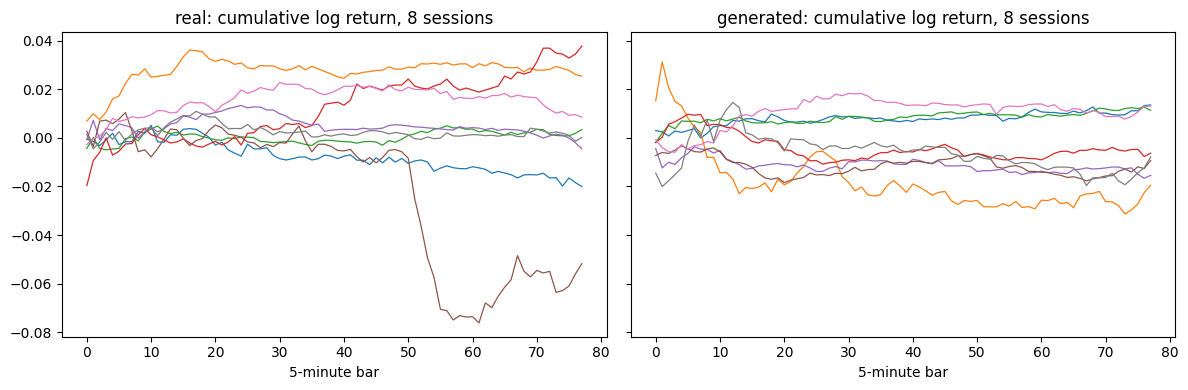

In [12]:
# Eyeball: eight generated sessions' cumulative log return, against eight real ones.
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
g = torch_generator("colab-plot-pick")
pick = torch.randperm(len(real), generator=g)[:8].numpy()
for ax, series, title in ((axes[0], real[pick], "real"), (axes[1], synth[:8], "generated")):
    ax.plot(np.cumsum(series[:, RET], axis=-1).T, lw=0.9)
    ax.set_title(f"{title}: cumulative log return, 8 sessions")
    ax.set_xlabel("5-minute bar")
plt.tight_layout(); plt.show()

## 6. Take the checkpoint with you

`checkpoints/` is gitignored on purpose (CLAUDE.md, data policy), so the checkpoint does not go
back through git. If Drive was mounted in §2 it is already saved there; otherwise download it
now, before the VM is reclaimed.

In [13]:
ckpt = CKPT_DIR / f"{cfg.name.lower()}_latest.pt"
print(f"{ckpt}  ({ckpt.stat().st_size / 1e6:.1f} MB)" if ckpt.exists() else f"MISSING: {ckpt}")

DOWNLOAD = not USE_DRIVE     # already on Drive? then nothing to do
if DOWNLOAD and ckpt.exists():
    from google.colab import files
    files.download(str(ckpt))

/content/drive/MyDrive/diff_model_checkpoints/full_latest.pt  (921.4 MB)


### Then, locally

```bash
cp ~/Downloads/full_latest.pt ~/projects/diff_model/checkpoints/
cd ~/projects/diff_model && source ~/.venvs/diff_model/bin/activate
python scripts/run_scorecard.py --checkpoint checkpoints/full_latest.pt
```

Note the scorecard defaults to the SMOKE codec and the SMOKE fit split — scoring a FULL
checkpoint means passing the FULL preset through as well, or the decoder applies the inverse of
a transform this model never saw. That plumbing is `02_baselines_and_scorecard.ipynb`'s job.